# Three-region logistic regression: public-library replication

This notebook compares the original custom NumPy logistic regression with the public-library scikit-learn implementation. The primary outcome is familiarity (`cagemate = 0`, `novel = 1`), using power and coherence from mPFC, MD, and NAc. Partner A (`exp1`) and partner B (`exp5`) are both retained.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SK = ROOT / 'outputs' / 'sklearn_three_region_replication'
REF = ROOT / 'Logistic_Regression_Results' / 'validation_auc_selected_5_train_1_validation_1_test' / 'nested_subject_loso'
assert SK.exists(), f'Missing scikit-learn results: {SK}'
assert REF.exists(), f'Missing reference results: {REF}'

## Task-level scikit-learn results

Each value is the mean across seven untouched test subjects.

In [2]:
sk_summary = pd.read_csv(SK / 'sklearn_model_summary.csv')
sk_summary.round(3)

,task,mean_test_accuracy,mean_test_balanced_accuracy,mean_test_auc,sem_test_auc
0,cagemate,0.529,0.529,0.491,0.143
1,novel,0.514,0.514,0.486,0.136
2,combined,0.586,0.586,0.587,0.120
3,familiarity,0.629,0.629,0.644,0.081


## Primary familiarity replication

The custom and scikit-learn models use identical observations, features, subject roles, standardization, L2 candidates, and validation rule. The conversion `C = 1 / (n × lambda)` matches their L2 objectives.

In [3]:
custom_summary = pd.read_csv(REF / 'familiarity' / 'csv' / 'familiarity_summary.csv').iloc[0]
sk_fam = sk_summary.loc[sk_summary['task'].eq('familiarity')].iloc[0]
comparison = pd.DataFrame({
    'implementation': ['Custom NumPy', 'scikit-learn'],
    'accuracy': [custom_summary['mean_test_accuracy'], sk_fam['mean_test_accuracy']],
    'balanced_accuracy': [custom_summary['mean_test_balanced_accuracy'], sk_fam['mean_test_balanced_accuracy']],
    'auc': [custom_summary['mean_test_auc'], sk_fam['mean_test_auc']],
    'auc_sem': [custom_summary['sem_test_auc'], sk_fam['sem_test_auc']],
})
comparison.round(3)

,implementation,accuracy,balanced_accuracy,auc,auc_sem
0,Custom NumPy,0.629,0.629,0.641,0.081
1,scikit-learn,0.629,0.629,0.644,0.081


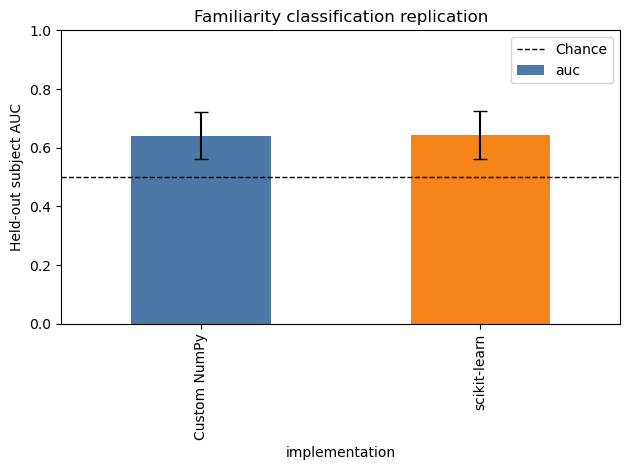

In [4]:
ax = comparison.plot.bar(x='implementation', y='auc', yerr='auc_sem', capsize=5, legend=False, color=['#4C78A8', '#F58518'])
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, label='Chance')
ax.set_ylim(0, 1)
ax.set_ylabel('Held-out subject AUC')
ax.set_title('Familiarity classification replication')
ax.legend()
plt.tight_layout()

## Direct prediction agreement

In [5]:
agreement = pd.read_csv(SK / 'custom_vs_sklearn_comparison.csv')
agreement.round(4)

,task,n_predictions,label_agreement,mean_absolute_probability_difference,maximum_absolute_probability_difference,probability_correlation
0,cagemate,70,0.8714,0.1202,0.9999,0.3322
1,novel,70,0.9143,0.0867,0.8492,0.6179
2,combined,140,0.9286,0.0560,0.5966,0.7650
3,familiarity,140,1.0000,0.0075,0.1733,0.9945


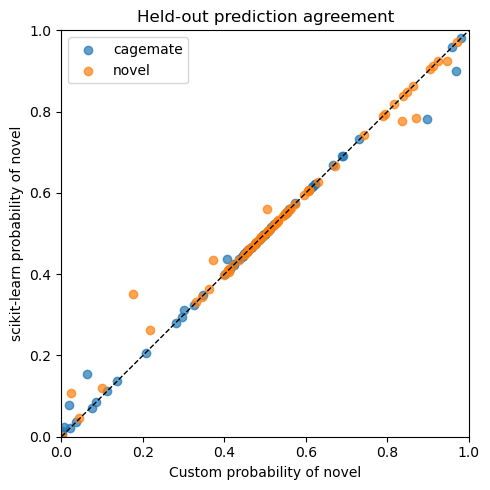

In [6]:
sk_pred = pd.read_csv(SK / 'familiarity_fold_predictions.csv')
custom_pred = pd.read_csv(REF / 'familiarity' / 'csv' / 'familiarity_fold_predictions.csv')
pred = sk_pred.merge(
    custom_pred[['split_name', 'interaction_id', 'predicted_probability_B']],
    on=['split_name', 'interaction_id'], validate='one_to_one'
)
fig, ax = plt.subplots(figsize=(5, 5))
for condition, group in pred.groupby('condition'):
    ax.scatter(group['predicted_probability_B'], group['predicted_probability_class_1'], alpha=.7, label=condition)
ax.plot([0, 1], [0, 1], '--', color='black', linewidth=1)
ax.set(xlabel='Custom probability of novel', ylabel='scikit-learn probability of novel', xlim=(0, 1), ylim=(0, 1))
ax.set_title('Held-out prediction agreement')
ax.legend()
plt.tight_layout()

## Familiarity performance by held-out subject

In [7]:
folds = pd.read_csv(SK / 'familiarity_fold_results.csv')
folds[['test_subject', 'selected_l2', 'sklearn_C_final_fit', 'test_accuracy', 'test_balanced_accuracy', 'test_auc']].round(3)

,test_subject,selected_l2,sklearn_C_final_fit,test_accuracy,test_balanced_accuracy,test_auc
0,1.1,0.01,0.833,0.75,0.75,0.72
1,1.2,1.00,0.008,0.75,0.75,0.80
2,2.1,1.00,0.008,0.35,0.35,0.29
3,2.2,0.01,0.833,0.60,0.60,0.66
4,3.1,1.00,0.008,0.45,0.45,0.55
5,3.2,1.00,0.008,0.90,0.90,0.96
6,4.1,1.00,0.008,0.60,0.60,0.53


## Interpretation

The public-library model closely reproduces the primary familiarity result: accuracy is identical, AUC differs by about 0.003, all 140 held-out classifications agree, and predicted probabilities correlate at approximately 0.994. This supports the conclusion that the familiarity result is not an artifact of the custom optimizer. The sample contains only seven subjects, so fold variability and uncertainty should remain visible when reporting the result.

In [8]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    log_loss,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

In [9]:
csv_path = Path(
    r"C:\Users\sjs93\Downloads\safe_balanced_3_regions.csv"
)

df = pd.read_csv(csv_path)

print(df.shape)
df.head()

(8400, 23)


,Unnamed: 0,subject,recording,event,partner,trial,condition,event_length,distance,velocity_mouse1,...,front_orientation_mouse1,front_orientation_mouse2,rump_orientation_mouse1,rump_orientation_mouse2,body_angle_mouse1,body_angle_mouse2,band,metric,region_or_pair,value
0,2,1.1,11_cage_p1_merged.rec,exp1 sniff,A,0,cagemate,3656,275.719717,0.28054,...,2.59179,1.359749,2.320077,0.940801,2.489983,0.0,Delta,power,MD,-27.343484
1,37,1.1,11_cage_p1_merged.rec,exp1 sniff,A,0,cagemate,3656,275.719717,0.28054,...,2.59179,1.359749,2.320077,0.940801,2.489983,0.0,Theta,power,MD,-14.895568
2,72,1.1,11_cage_p1_merged.rec,exp1 sniff,A,0,cagemate,3656,275.719717,0.28054,...,2.59179,1.359749,2.320077,0.940801,2.489983,0.0,Beta,power,MD,-16.873366
3,107,1.1,11_cage_p1_merged.rec,exp1 sniff,A,0,cagemate,3656,275.719717,0.28054,...,2.59179,1.359749,2.320077,0.940801,2.489983,0.0,Low gamma,power,MD,-30.992042
4,142,1.1,11_cage_p1_merged.rec,exp1 sniff,A,0,cagemate,3656,275.719717,0.28054,...,2.59179,1.359749,2.320077,0.940801,2.489983,0.0,High gamma,power,MD,-14.914988


In [10]:
pd.crosstab(
    [df["condition"], df["partner"]],
    df["event"]
)

event              exp1 sniff  exp5 sniff
condition partner                        
cagemate  A              2100           0
          B                 0        2100
novel     A              2100           0
          B                 0        2100

In [11]:
df_model = df[
    df["metric"].isin(["power", "coherence"])
].copy()

df_model["metric"].value_counts()

metric
power        2100
coherence    2100
Name: count, dtype: int64

In [12]:
for column in ["subject", "partner", "condition"]:
    df_model[column] = df_model[column].astype(str)

In [14]:
id_columns = [
    "subject",
    "recording",
    "event",
    "partner",
    "trial",
    "condition",
]

for column in ["subject", "partner", "condition"]:
    df_model[column] = df_model[column].astype(str)

In [15]:
power = (
    df_model[df_model["metric"] == "power"]
    .pivot_table(
        index=id_columns,
        columns=["band", "region_or_pair"],
        values="value",
        aggfunc="first",
    )
)

power.columns = [
    f"{band}__power__{region}"
    for band, region in power.columns
]

power = power.reset_index()

print(power.shape)
power.head()

(140, 21)


,subject,recording,event,partner,trial,condition,Beta__power__MD,Beta__power__NAc,Beta__power__mPFC,Delta__power__MD,...,Delta__power__mPFC,High gamma__power__MD,High gamma__power__NAc,High gamma__power__mPFC,Low gamma__power__MD,Low gamma__power__NAc,Low gamma__power__mPFC,Theta__power__MD,Theta__power__NAc,Theta__power__mPFC
0,1.1,11_cage_p1_merged.rec,exp1 sniff,A,0,cagemate,-16.873366,-11.482463,40.667169,-27.343484,...,17.715087,-14.914988,22.060612,33.048429,-30.992042,15.197900,45.522987,-14.895568,-23.268667,-32.846423
1,1.1,11_cage_p1_merged.rec,exp1 sniff,A,1,cagemate,-35.238998,-12.297930,26.812311,19.966011,...,-29.707704,-36.843250,17.226411,9.857070,-29.490091,5.184229,23.473058,-46.164614,-35.088967,-18.213303
2,1.1,11_cage_p1_merged.rec,exp1 sniff,A,2,cagemate,-38.053978,-14.221190,6.475723,-19.110787,...,34.847624,-25.386434,37.083928,50.204793,-25.038653,2.868391,15.490602,-59.831752,-16.802666,9.431389
3,1.1,11_cage_p1_merged.rec,exp1 sniff,A,3,cagemate,-35.113263,23.083722,47.172799,-19.015816,...,-13.693997,-16.731346,36.046405,46.056295,-37.808599,9.651674,25.366734,-34.802940,-28.329480,-6.184883
4,1.1,11_cage_p1_merged.rec,exp1 sniff,A,4,cagemate,-23.659127,-16.605127,-9.944206,-34.456422,...,-51.831078,-31.316863,22.191643,3.204528,-44.415647,-18.006155,0.159314,-24.991428,-55.211316,-35.557448


In [16]:
coherence = (
    df_model[df_model["metric"] == "coherence"]
    .pivot_table(
        index=id_columns,
        columns=["band", "region_or_pair"],
        values="value",
        aggfunc="first",
    )
)

coherence.columns = [
    f"{band}__coherence__{region_pair}"
    for band, region_pair in coherence.columns
]

coherence = coherence.reset_index()

print(coherence.shape)
coherence.head()

(140, 21)


,subject,recording,event,partner,trial,condition,Beta__coherence__NAc_MD,Beta__coherence__mPFC_MD,Beta__coherence__mPFC_NAc,Delta__coherence__NAc_MD,...,Delta__coherence__mPFC_NAc,High gamma__coherence__NAc_MD,High gamma__coherence__mPFC_MD,High gamma__coherence__mPFC_NAc,Low gamma__coherence__NAc_MD,Low gamma__coherence__mPFC_MD,Low gamma__coherence__mPFC_NAc,Theta__coherence__NAc_MD,Theta__coherence__mPFC_MD,Theta__coherence__mPFC_NAc
0,1.1,11_cage_p1_merged.rec,exp1 sniff,A,0,cagemate,4.424096,5.319176,9.035232,-30.937118,...,24.680488,-5.263231,6.926577,-7.346481,3.522089,4.933149,-7.832924,-16.658814,2.580142,-19.420233
1,1.1,11_cage_p1_merged.rec,exp1 sniff,A,1,cagemate,-2.309442,4.266972,0.584273,-19.361026,...,8.199880,-4.538547,-3.472822,-15.937728,6.833044,1.811698,4.529732,-12.511413,-4.210345,-1.316636
2,1.1,11_cage_p1_merged.rec,exp1 sniff,A,2,cagemate,4.882133,0.444452,-4.744025,34.159880,...,14.136418,-16.921154,-24.525741,3.378386,14.066572,8.600295,2.372369,6.712601,8.169239,8.249139
3,1.1,11_cage_p1_merged.rec,exp1 sniff,A,3,cagemate,-8.633283,-11.223361,-3.617860,-25.980509,...,8.116696,2.718823,18.326336,13.110611,0.721899,5.273749,-7.434952,-7.071400,-14.296849,-3.514383
4,1.1,11_cage_p1_merged.rec,exp1 sniff,A,4,cagemate,-9.437020,-22.916734,-6.469594,-6.192683,...,-39.682198,-7.506726,-13.377061,2.314296,2.160633,-18.391257,11.455185,-3.638682,-23.328738,-3.322967


In [17]:
wide = power.merge(
    coherence,
    on=id_columns,
    how="inner",
    validate="one_to_one",
)

print(wide.shape)
wide.head()

(140, 36)


,subject,recording,event,partner,trial,condition,Beta__power__MD,Beta__power__NAc,Beta__power__mPFC,Delta__power__MD,...,Delta__coherence__mPFC_NAc,High gamma__coherence__NAc_MD,High gamma__coherence__mPFC_MD,High gamma__coherence__mPFC_NAc,Low gamma__coherence__NAc_MD,Low gamma__coherence__mPFC_MD,Low gamma__coherence__mPFC_NAc,Theta__coherence__NAc_MD,Theta__coherence__mPFC_MD,Theta__coherence__mPFC_NAc
0,1.1,11_cage_p1_merged.rec,exp1 sniff,A,0,cagemate,-16.873366,-11.482463,40.667169,-27.343484,...,24.680488,-5.263231,6.926577,-7.346481,3.522089,4.933149,-7.832924,-16.658814,2.580142,-19.420233
1,1.1,11_cage_p1_merged.rec,exp1 sniff,A,1,cagemate,-35.238998,-12.297930,26.812311,19.966011,...,8.199880,-4.538547,-3.472822,-15.937728,6.833044,1.811698,4.529732,-12.511413,-4.210345,-1.316636
2,1.1,11_cage_p1_merged.rec,exp1 sniff,A,2,cagemate,-38.053978,-14.221190,6.475723,-19.110787,...,14.136418,-16.921154,-24.525741,3.378386,14.066572,8.600295,2.372369,6.712601,8.169239,8.249139
3,1.1,11_cage_p1_merged.rec,exp1 sniff,A,3,cagemate,-35.113263,23.083722,47.172799,-19.015816,...,8.116696,2.718823,18.326336,13.110611,0.721899,5.273749,-7.434952,-7.071400,-14.296849,-3.514383
4,1.1,11_cage_p1_merged.rec,exp1 sniff,A,4,cagemate,-23.659127,-16.605127,-9.944206,-34.456422,...,-39.682198,-7.506726,-13.377061,2.314296,2.160633,-18.391257,11.455185,-3.638682,-23.328738,-3.322967


In [18]:
feature_columns = [
    column
    for column in wide.columns
    if "__power__" in column
    or "__coherence__" in column
]

print("Interactions:", len(wide))
print("Network features:", len(feature_columns))
print("Subjects:", wide["subject"].nunique())

Interactions: 140
Network features: 30
Subjects: 7


In [19]:
wide["target"] = wide["condition"].map(
    {
        "cagemate": 0,
        "novel": 1,
    }
)

wide[["condition", "target"]].value_counts()

condition  target
cagemate   0         70
novel      1         70
Name: count, dtype: int64

In [20]:
X = wide[feature_columns].to_numpy(dtype=float)
y = wide["target"].to_numpy(dtype=int)
subjects = wide["subject"].to_numpy(dtype=str)

print(X.shape)
print(y.shape)

(140, 30)
(140,)


In [21]:
def make_subject_folds(subjects, seed=42):
    unique_subjects = tuple(sorted(set(subjects)))

    rng = np.random.default_rng(seed)
    validation_order = np.asarray(
        unique_subjects,
        dtype=object,
    )

    # Find a permutation where the validation subject
    # is never the same as the test subject.
    while True:
        validation_order = rng.permutation(
            validation_order
        )

        valid = all(
            test_subject != validation_subject
            for test_subject, validation_subject
            in zip(unique_subjects, validation_order)
        )

        if valid:
            break

    folds = []

    for test_subject, validation_subject in zip(
        unique_subjects,
        validation_order,
    ):
        validation_subject = str(validation_subject)

        train_subjects = [
            subject
            for subject in unique_subjects
            if subject not in {
                test_subject,
                validation_subject,
            }
        ]

        folds.append(
            {
                "train_subjects": train_subjects,
                "validation_subject": validation_subject,
                "test_subject": test_subject,
            }
        )

    return folds

In [22]:
folds = make_subject_folds(subjects, seed=42)

pd.DataFrame(folds)

,train_subjects,validation_subject,test_subject
0,"[1.2, 2.1, 3.1, 3.2, 4.1]",2.2,1.1
1,"[1.1, 2.1, 2.2, 3.1, 3.2]",4.1,1.2
2,"[1.2, 2.2, 3.1, 3.2, 4.1]",1.1,2.1
3,"[1.1, 1.2, 3.1, 3.2, 4.1]",2.1,2.2
4,"[1.1, 2.1, 2.2, 3.2, 4.1]",1.2,3.1
5,"[1.1, 1.2, 2.1, 2.2, 4.1]",3.1,3.2
6,"[1.1, 1.2, 2.1, 2.2, 3.1]",3.2,4.1


In [23]:
l2_candidates = [
    0.0001,
    0.001,
    0.01,
    0.1,
    1.0,
]

In [24]:
def fit_sklearn_logistic(X_fit, y_fit, l2):
    # Calculate scaling only from the fitting data.
    scaler = StandardScaler()

    X_fit_scaled = scaler.fit_transform(X_fit)

    # Convert custom lambda to scikit-learn C.
    n_fit = len(y_fit)
    C = 1 / (n_fit * l2)

    model = LogisticRegression(
        penalty="l2",
        C=C,
        solver="lbfgs",
        fit_intercept=True,
        max_iter=10_000,
        tol=1e-12,
        random_state=42,
    )

    model.fit(X_fit_scaled, y_fit)

    return scaler, model

In [25]:
def select_l2(
    X_train,
    y_train,
    X_validation,
    y_validation,
):
    candidate_results = []

    for l2 in l2_candidates:
        scaler, model = fit_sklearn_logistic(
            X_train,
            y_train,
            l2,
        )

        X_validation_scaled = scaler.transform(
            X_validation
        )

        probabilities = model.predict_proba(
            X_validation_scaled
        )[:, 1]

        predictions = (
            probabilities >= 0.5
        ).astype(int)

        candidate_results.append(
            {
                "l2": l2,
                "validation_auc": roc_auc_score(
                    y_validation,
                    probabilities,
                ),
                "validation_balanced_accuracy":
                    balanced_accuracy_score(
                        y_validation,
                        predictions,
                    ),
                "validation_loss": log_loss(
                    y_validation,
                    probabilities,
                    labels=[0, 1],
                ),
            }
        )

    candidate_table = pd.DataFrame(
        candidate_results
    )

    # Same selection order as the reference:
    # 1. Highest validation AUC
    # 2. Highest balanced accuracy
    # 3. Lowest validation loss
    # 4. Strongest L2 if everything ties
    candidate_table = candidate_table.sort_values(
        by=[
            "validation_auc",
            "validation_balanced_accuracy",
            "validation_loss",
            "l2",
        ],
        ascending=[
            False,
            False,
            True,
            False,
        ],
    )

    selected_l2 = candidate_table.iloc[0]["l2"]

    return selected_l2, candidate_table

In [26]:
fold_results = []
all_predictions = []
all_coefficients = []

for fold_number, fold in enumerate(folds, start=1):
    train_mask = np.isin(
        subjects,
        fold["train_subjects"],
    )

    validation_mask = (
        subjects == fold["validation_subject"]
    )

    test_mask = (
        subjects == fold["test_subject"]
    )

    X_train = X[train_mask]
    y_train = y[train_mask]

    X_validation = X[validation_mask]
    y_validation = y[validation_mask]

    X_test = X[test_mask]
    y_test = y[test_mask]

    # Select L2 using only the five training
    # subjects and one validation subject.
    selected_l2, tuning_table = select_l2(
        X_train,
        y_train,
        X_validation,
        y_validation,
    )

    # After selection, combine training and
    # validation subjects for the final fit.
    final_fit_mask = train_mask | validation_mask

    X_final = X[final_fit_mask]
    y_final = y[final_fit_mask]

    scaler, model = fit_sklearn_logistic(
        X_final,
        y_final,
        selected_l2,
    )

    # Apply training-derived scaling to test data.
    X_test_scaled = scaler.transform(X_test)

    test_probability = model.predict_proba(
        X_test_scaled
    )[:, 1]

    test_prediction = (
        test_probability >= 0.5
    ).astype(int)

    fold_results.append(
        {
            "fold": fold_number,
            "test_subject": fold["test_subject"],
            "validation_subject":
                fold["validation_subject"],
            "selected_l2": selected_l2,
            "test_accuracy": accuracy_score(
                y_test,
                test_prediction,
            ),
            "test_balanced_accuracy":
                balanced_accuracy_score(
                    y_test,
                    test_prediction,
                ),
            "test_auc": roc_auc_score(
                y_test,
                test_probability,
            ),
        }
    )

    # Save each held-out prediction.
    test_rows = wide.loc[test_mask].copy()

    for local_index, (_, row) in enumerate(
        test_rows.iterrows()
    ):
        all_predictions.append(
            {
                "fold": fold_number,
                "subject": row["subject"],
                "event": row["event"],
                "partner": row["partner"],
                "condition": row["condition"],
                "actual_label":
                    int(y_test[local_index]),
                "predicted_label":
                    int(test_prediction[local_index]),
                "probability_novel":
                    float(test_probability[local_index]),
            }
        )

    # Coefficients are standardized coefficients.
    for feature, coefficient in zip(
        feature_columns,
        model.coef_[0],
    ):
        all_coefficients.append(
            {
                "fold": fold_number,
                "test_subject":
                    fold["test_subject"],
                "feature": feature,
                "coefficient":
                    float(coefficient),
            }
        )

In [27]:
fold_results = pd.DataFrame(fold_results)
fold_results

,fold,test_subject,validation_subject,selected_l2,test_accuracy,test_balanced_accuracy,test_auc
0,1,1.1,2.2,0.01,0.75,0.75,0.72
1,2,1.2,4.1,1.00,0.75,0.75,0.80
2,3,2.1,1.1,1.00,0.35,0.35,0.29
3,4,2.2,2.1,0.01,0.60,0.60,0.66
4,5,3.1,1.2,1.00,0.45,0.45,0.55
5,6,3.2,3.1,1.00,0.90,0.90,0.96
6,7,4.1,3.2,1.00,0.60,0.60,0.53


In [28]:
mean_accuracy = fold_results[
    "test_accuracy"
].mean()

mean_balanced_accuracy = fold_results[
    "test_balanced_accuracy"
].mean()

mean_auc = fold_results[
    "test_auc"
].mean()

sem_auc = (
    fold_results["test_auc"].std(ddof=1)
    / np.sqrt(len(fold_results))
)

print(f"Accuracy: {mean_accuracy:.3f}")
print(
    "Balanced accuracy:",
    f"{mean_balanced_accuracy:.3f}",
)
print(f"AUC: {mean_auc:.3f}")
print(f"AUC SEM: {sem_auc:.3f}")

Accuracy: 0.629
Balanced accuracy: 0.629
AUC: 0.644
AUC SEM: 0.081


In [29]:
predictions_df = pd.DataFrame(all_predictions)

pd.crosstab(
    predictions_df["actual_label"],
    predictions_df["predicted_label"],
    rownames=["Actual"],
    colnames=["Predicted"],
)

Predicted,0,1
Actual,,
0,47,23
1,29,41


In [30]:
coefficients_df = pd.DataFrame(
    all_coefficients
)

coefficient_summary = (
    coefficients_df
    .groupby("feature")
    .agg(
        mean_coefficient=("coefficient", "mean"),
        mean_absolute_coefficient=(
            "coefficient",
            lambda x: np.mean(np.abs(x)),
        ),
        coefficient_sem=(
            "coefficient",
            lambda x:
                x.std(ddof=1) / np.sqrt(len(x)),
        ),
    )
    .reset_index()
    .sort_values(
        "mean_absolute_coefficient",
        ascending=False,
    )
)

coefficient_summary.head(10)

,feature,mean_coefficient,mean_absolute_coefficient,coefficient_sem
9,Delta__power__MD,-0.569541,0.569541,0.273901
3,Beta__power__MD,0.273082,0.273082,0.129326
20,Low gamma__coherence__mPFC_NAc,0.254212,0.254212,0.115477
14,High gamma__coherence__mPFC_NAc,0.248911,0.248911,0.127085
25,Theta__coherence__mPFC_MD,-0.243736,0.243736,0.107001
29,Theta__power__mPFC,-0.226266,0.226266,0.102247
21,Low gamma__power__MD,0.221991,0.221991,0.091853
12,High gamma__coherence__NAc_MD,0.204895,0.204895,0.107560
4,Beta__power__NAc,-0.173907,0.185500,0.116792
11,Delta__power__mPFC,0.088716,0.154443,0.096979


In [31]:
output_dir = Path(
    "outputs/my_sklearn_familiarity_model"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

fold_results.to_csv(
    output_dir / "fold_results.csv",
    index=False,
)

predictions_df.to_csv(
    output_dir / "predictions.csv",
    index=False,
)

coefficients_df.to_csv(
    output_dir / "coefficients_by_fold.csv",
    index=False,
)

coefficient_summary.to_csv(
    output_dir / "coefficient_summary.csv",
    index=False,
)